## Hugging Face: BERT

To run this file __torch__ and __transfromers__ should be installed. <br>
We excluded BERT model from the further steps, because it requires large memory space.<br>
__Torch__ and __transformers__ are also excluded from __requirements.txt__ in order not to overload it.

In [1]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch
import pandas as pd
from tqdm import tqdm

/home/ubuntu/.venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


ModuleNotFoundError: No module named 'torch'

In [13]:
all_data_df = pd.read_csv('all_data.csv')

all_data_df = all_data_df.dropna(subset=["text"])

In [14]:
from transformers import AutoTokenizer

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("nlptown/bert-base-multilingual-uncased-sentiment")

# Define truncation function
def truncate_text(text, max_length=512):
    encoded = tokenizer.encode(
        str(text),
        max_length=max_length,
        truncation=True,
        add_special_tokens=True
    )
    return tokenizer.decode(encoded, skip_special_tokens=True)

# Apply to DataFrame
all_data_df["truncated_text"] = all_data_df["text"].apply(truncate_text)

In [15]:
from transformers import pipeline
from tqdm import tqdm
from tqdm import TqdmMonitorWarning

classifier = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment", device=0)

texts = all_data_df["truncated_text"].astype(str).tolist()
batch_size = 32
results = []

for i in tqdm(range(0, len(texts), batch_size), desc="Processing"):
    batch = texts[i:i+batch_size]
    batch_result = classifier(batch, truncation=True)
    results.extend(batch_result)

all_data_df["hf_sentiment"] = [r["score"] for r in results]

Device set to use cuda:0
Processing: 100%|██████████| 660/660 [03:35<00:00,  3.06it/s]


In [16]:
all_data_df["hf_sentiment"] = [r["label"] for r in results]

In [17]:
all_data_df["rating_x"] = pd.to_numeric(all_data_df["rating_x"], errors='coerce')

all_data_df["hf_sentiment"] = all_data_df["hf_sentiment"].astype(str).str.extract(r"(\d)").astype(float)

mismatches = all_data_df[all_data_df["rating_x"] != all_data_df["hf_sentiment"]]


print(f"Not matching cases: {len(mismatches)} из {len(all_data_df)} ({len(mismatches)/len(all_data_df)*100:.2f}%)")


mismatches[["text", "rating_x", "hf_sentiment"]].sample(15)

Not matching cases: 4766 из 21098 (22.59%)


,text,rating_x,hf_sentiment
10912,It took three attempts to rent an RV. The firs...,3.0,2.0
16275,Fast and friendly service that is always willi...,5.0,4.0
3352,I could not enter my information about wheel c...,4.0,1.0
20208,Eddie Mason was good to work with. He is pers...,5.0,4.0
13666,Car hire was arranged from Reykavik domestic a...,3.0,2.0
6515,easy to use. prices good,5.0,4.0
13129,The house and property are beautiful and it wa...,5.0,1.0
20125,"Our agent, Clyde, was very professional and pr...",4.0,5.0
11104,Both van drivers to and from the airport did n...,3.0,2.0
14899,Rush My Passport was a good company to work with.,4.0,5.0


Accuracy: 0.7741
Precision: 0.8351
Recall: 0.7741
F1-score: 0.7982
Confusion Matrix:
[[ 5328   290    55    24    48]
 [  270   132    37    15     8]
 [  166   232   167    59    24]
 [   89   110   235   575   495]
 [  241   127   214  2027 10130]]


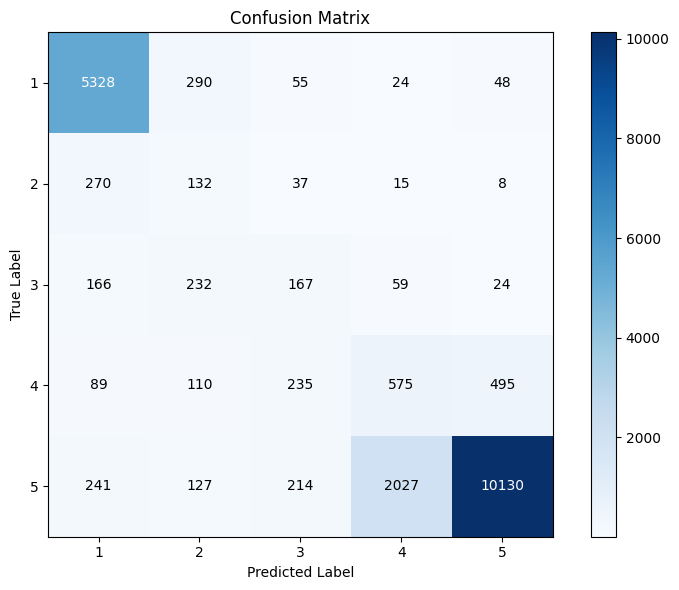

In [19]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# True labels
true_labels = all_data_df["rating_x"].tolist()

# Predicted labels
pred_labels = all_data_df["hf_sentiment"].tolist()


# Calculate metrics
accuracy = accuracy_score(true_labels, pred_labels)
precision, recall, f1, _ = precision_recall_fscore_support(true_labels, pred_labels, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels)
print("Confusion Matrix:")
print(cm)

# Visualize confusion matrix with matplotlib
plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(set(true_labels)))
plt.xticks(tick_marks, tick_marks + 1)
plt.yticks(tick_marks, tick_marks + 1)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Add numbers inside the matrix cells
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

# Calculate False Positives and False Neg


In [21]:
from sklearn.metrics import classification_report, mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr
import numpy as np

# Classification report and accuracy
print(f"Accuracy for BERT: {accuracy_score(true_labels, pred_labels):.4f}\n")
print("Classification Report for BERT:")
print(classification_report(true_labels, pred_labels, digits=4))

print("------------------------------------------------------")

# Regression metrics
# Since labels are ordinal, we can treat them as numeric values directly
mae = mean_absolute_error(true_labels, pred_labels)
mse = mean_squared_error(true_labels, pred_labels)
rmse = np.sqrt(mse)
r2 = r2_score(true_labels, pred_labels)
pearson_corr, _ = pearsonr(true_labels, pred_labels)

print("--- BERT Regression ---")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"Pearson: {pearson_corr:.4f}")
print("------------------------------------------------------")


Accuracy for BERT: 0.7741

Classification Report for BERT:
              precision    recall  f1-score   support

         1.0     0.8743    0.9274    0.9001      5745
         2.0     0.1481    0.2857    0.1951       462
         3.0     0.2359    0.2577    0.2463       648
         4.0     0.2130    0.3823    0.2735      1504
         5.0     0.9463    0.7952    0.8642     12739

    accuracy                         0.7741     21098
   macro avg     0.4835    0.5297    0.4958     21098
weighted avg     0.8351    0.7741    0.7982     21098

------------------------------------------------------
--- BERT Regression ---
MAE: 0.3182
MSE: 0.6084
RMSE: 0.7800
R²: 0.8031
Pearson: 0.9072
------------------------------------------------------


## 1. Check Task Setup and Label Spaces
#### BERT:
Predicts fine-grained ratings (1 to 5 stars), i.e., a multi-class classification with 5 classes.

#### VADER and TextBlob: ([From this notebook](https://github.com/pnppl1/apr25_bde_int_supply/blob/main/3_data_consumption/Sentiment_Analysis_Comparison.ipynb))
Usually produce 3-class sentiment labels (negative, neutral, positive).

This means the classification tasks and label spaces differ, so direct comparison of classification metrics needs caution. BERT’s 5-class setup is more detailed.

## 2. Compare Accuracy and Classification Metrics
BERT’s accuracy (~0.77) is slightly higher than VADER (0.76) and better than TextBlob (0.71).

BERT provides detailed class-level metrics for 5 classes; VADER/TextBlob provide metrics on 3 sentiment classes.

Weighted averages show BERT’s precision/recall/F1 are generally better, especially for major classes (1 and 5 stars).

## 3. Interpret Regression Metrics
Regression metrics (MAE, MSE, RMSE, R², Pearson) are based on numeric rating values:

BERT performs best with:

Lowest MAE (0.3182 vs 0.4411 and 0.6496),

Higher R² (0.8031 vs 0.5283 and 0.3190),

Highest Pearson correlation (0.9072 vs 0.7294 and 0.6323).

This means BERT predictions correlate much better with true ratings numerically.

Note: VADER has lower MSE and RMSE than BERT, which might be due to different scales or distributions.

## 4. What to Keep in Mind When Comparing
#### Label Granularity:
BERT works on a 5-star scale, VADER/TextBlob on 3 sentiment classes. This inherently affects accuracy and metrics.


#### Use-case Suitability:

BERT is better if you want fine-grained sentiment/rating prediction.

VADER/TextBlob are simpler and quicker but may be less precise for rating tasks.

In [22]:
all_data_df

,name,country,rating_x,title,text,date_of_experience,has_reply,company_x,company_y,website,rating_y,number_review,domain,5_star_percentage,4_star_percentage,3_star_percentage,2_star_percentage,1_star_percentage,truncated_text,hf_sentiment
0,Przemysław Rosuł,PL,1.0,Ignoring the specified pickup time,Ignoring the specified pickup time. Providing ...,2025-05-13,0.0,www.viator.com,Viator.com,www.viator.com,4.4,260639.0,['Travel Agency'],72%,9%,4%,3%,12%,ignoring the specified pickup time. providing ...,1.0
1,kathy mrozek,US,5.0,Athens Evening food tour with Katrina,"Katrina, the tour guide was fabulous! She mad...",2025-05-15,0.0,www.viator.com,Viator.com,www.viator.com,4.4,260639.0,['Travel Agency'],72%,9%,4%,3%,12%,"katrina, the tour guide was fabulous! she made...",5.0
2,MARY MURRAY,US,5.0,All you need for travel with confidence,A great app! My excursions have been awesome! ...,2025-05-12,0.0,www.viator.com,Viator.com,www.viator.com,4.4,260639.0,['Travel Agency'],72%,9%,4%,3%,12%,a great app! my excursions have been awesome! ...,5.0
3,K Shay Smith,MX,1.0,I booked the excursion and paid the…,I booked the excursion and paid the money up f...,2025-05-12,0.0,www.viator.com,Viator.com,www.viator.com,4.4,260639.0,['Travel Agency'],72%,9%,4%,3%,12%,i booked the excursion and paid the money up f...,1.0
4,Jeff Paine,US,5.0,Great food tour of Prague. Great conversation ...,Great food tour of Prague,2025-05-07,0.0,www.viator.com,Viator.com,www.viator.com,4.4,260639.0,['Travel Agency'],72%,9%,4%,3%,12%,great food tour of prague,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21110,Asma,US,1.0,I rented a car with Expedia and paid…,I rented a car with Expedia and paid the money...,2025-02-08,0.0,www.expedia.com,Expedia,www.expedia.com,1.2,10149.0,"['Travel Aggregator', 'Travel Agency']",4%,<1%,<1%,2%,92%,i rented a car with expedia and paid the money...,1.0
21111,Algirdas Dembinskas,US,1.0,Platinum user review,I’ve been using Expedia frequently for over 10...,2025-02-16,0.0,www.expedia.com,Expedia,www.expedia.com,1.2,10149.0,"['Travel Aggregator', 'Travel Agency']",4%,<1%,<1%,2%,92%,i ve been using expedia frequently for over 10...,2.0
21112,Erin McLaughlin,US,1.0,NEVER book a flight through Expedia,NEVER book a flight through Expedia. “Fully re...,2025-02-15,0.0,www.expedia.com,Expedia,www.expedia.com,1.2,10149.0,"['Travel Aggregator', 'Travel Agency']",4%,<1%,<1%,2%,92%,never book a flight through expedia. fully ref...,1.0
21113,Lane Rosen,US,1.0,Expedia a Very deceptive company,Very deceptive company. Charge double the reg...,2025-02-14,0.0,www.expedia.com,Expedia,www.expedia.com,1.2,10149.0,"['Travel Aggregator', 'Travel Agency']",4%,<1%,<1%,2%,92%,very deceptive company. charge double the regu...,1.0


In [23]:
all_data_df.to_csv('reviews_data.csv', index=False)